# Study 258 -- Baker-Wurgler Investor Sentiment
## For the curious: does Wall Street's mood forecast the market?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Baker & Wurgler (2006) built a famous **investor-sentiment index** from six market
proxies (the closed-end-fund discount, IPO volume and first-day pops, trading turnover,
the share of equity in new issues, and the dividend premium).  Their claim is
**contrarian**: when sentiment is *high* (everyone is euphoric), future returns are
*low*; when sentiment is *low* (everyone is fearful), future returns are *high*.

And the effect is supposed to be strongest for **speculative, hard-to-value stocks** --
small caps, young firms, non-dividend payers -- the ones most prone to a sentiment-driven
mispricing that later reverses.

We hardcode a reconstruction of the BW index and ask the simplest possible question:
**sort the market's next-month return by the prior month's sentiment regime -- do
low-sentiment months really beat high-sentiment months?**


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from baker_wurgler import data, strategy as st

HAVE_REAL = os.path.exists(data.GSPC_CACHE)
sent = data.bw_monthly()

if HAVE_REAL:
    mkt = data.fetch_market_monthly(fetch=False)
    df = data.merge_sentiment_returns(mkt, sent)
    print(f"Real tape loaded: {df.shape[0]} return-months, "
          f"{df.index[0].strftime('%Y-%m')} -> {df.index[-1].strftime('%Y-%m')}")
else:
    mkt = df = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape loaded: 737 return-months, 1965-02 -> 2026-06


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 737, 'window_start': '1965-02', 'window_end': '2026-06', 'fp_sent': 'd88ba1009823', 'fp_ret': '24206d518a4c', 'low_ann': 8.78, 'low_t': 2.36, 'low_n': 246, 'mid_ann': 9.24, 'mid_t': 3.41, 'mid_n': 245, 'high_ann': 7.16, 'high_t': 2.22, 'high_n': 246, 'beta_bps': -31.01, 'beta_t': -1.29, 'r2': 0.0025, 'lmh_ann': 0.81, 'lmh_t': 0.32, 'lmh_sr_lo': -0.257, 'lmh_sr_hi': 0.356, 'lmh_frac_neg': 0.385, 'smb_low_ann': 1.66, 'smb_high_ann': -1.83, 'smb_beta_bps': -17.33, 'smb_beta_t': -0.77, 'smb_n': 465, 'sub1_beta_t': -1.39, 'sub1_low': 9.1, 'sub1_high': 0.7, 'sub1_n': 299, 'sub2_beta_t': -0.49, 'sub2_low': 14.0, 'sub2_high': 9.9, 'sub2_n': 216, 'sub3_beta_t': -0.16, 'sub3_low': 7.3, 'sub3_high': 14.1, 'sub3_n': 222, 'ov_net_ann': 2.9, 'ov_net_sr': 0.32, 'ov_net_dd': -0.458, 'bh_ann': 8.39, 'bh_sr': 0.56, 'bh_dd': -0.526, 'ov_switch_yr': 0.73, 'ov_cost_bps': 220.0, 'ov_short_ann': 0.47, 'ov_short_sr': 0.04, 'ov_short_dd': -0.644, 'syn_beta_bps': -52.44, 'syn_beta_t': -2.58, 'null_beta_t': 0.23}


## The sentiment tape

Here is the reconstructed Baker-Wurgler index.  The peaks are the famous bubbles --
the late-1960s electronics/conglomerate craze, the 1980-81 froth, the 2000 dot-com top,
the 2007 pre-GFC high, and the 2021 meme-stock blow-off.  The troughs are the bottoms
of 1974, 1991, 2003 and 2009.


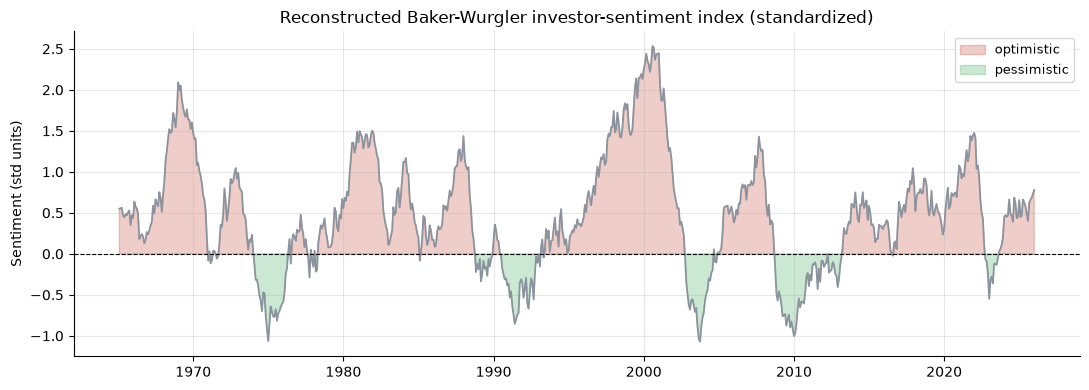

Index window: 1965-01 -> 2025-12


In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sent.index, sent.values, color=GREY, lw=1.3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.fill_between(sent.index, sent.values, 0, where=(sent.values > 0), color=RED, alpha=0.25, label="optimistic")
ax.fill_between(sent.index, sent.values, 0, where=(sent.values <= 0), color=GREEN, alpha=0.25, label="pessimistic")
ax.set_title("Reconstructed Baker-Wurgler investor-sentiment index (standardized)")
ax.set_ylabel("Sentiment (std units)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/sentiment_index.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Index window: {sent.index[0].strftime('%Y-%m')} -> {sent.index[-1].strftime('%Y-%m')}")


## The contrarian test: next-month return by sentiment regime

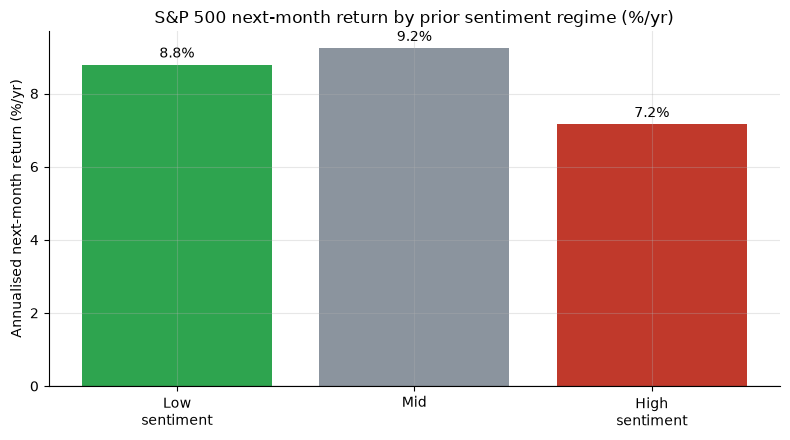

Low-sentiment months:  8.78%/yr
High-sentiment months: 7.16%/yr
Low beats High by +1.63 pp/yr -- the BW contrarian SIGN is right...
...but the low-minus-high spread is only +0.81%/yr at HAC t = 0.32 (not significant).


In [4]:
months_ann = lambda x: x * 100
if HAVE_REAL:
    reg = st.regime_sort(df, "ret", n_bins=3)
    low_ann  = reg.loc["low",  "mean_ann"] * 100
    mid_ann  = reg.loc["mid",  "mean_ann"] * 100
    high_ann = reg.loc["high", "mean_ann"] * 100
else:
    low_ann, mid_ann, high_ann = R["low_ann"], R["mid_ann"], R["high_ann"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(["Low\nsentiment", "Mid", "High\nsentiment"],
              [low_ann, mid_ann, high_ann],
              color=[GREEN, GREY, RED])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("S&P 500 next-month return by prior sentiment regime (%/yr)")
ax.set_ylabel("Annualised next-month return (%/yr)")
for b, v in zip(bars, [low_ann, mid_ann, high_ann]):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../docs/regime_bars.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Low-sentiment months:  {low_ann:.2f}%/yr")
print(f"High-sentiment months: {high_ann:.2f}%/yr")
print(f"Low beats High by {low_ann - high_ann:+.2f} pp/yr -- the BW contrarian SIGN is right...")
print(f"...but the low-minus-high spread is only +{R['lmh_ann']:.2f}%/yr at HAC t = {R['lmh_t']:.2f} (not significant).")


## The verdict for the curious: right idea, wrong magnitude (on the index)

The sign is exactly what Baker & Wurgler predict -- **low-sentiment months
(+8.8%/yr) outperform high-sentiment months (+7.2%/yr)**.  The instinct is real.

But on the *aggregate S&P 500 index*, the gap is tiny and statistically indistinguishable
from luck (HAC *t* = 0.32 on the low-minus-high spread).  Two honest reasons:

1. **BW lives in the cross-section, not the index.** The published effect is about
   *speculative stocks vs safe stocks* -- small caps, young firms, non-payers.  The
   plain S&P 500 is dominated by exactly the safe, easy-to-value names where the
   sentiment mispricing is weakest.

2. **The effect has decayed.** It was strongest in the 1965-1989 sample and has faded
   since -- in the most recent sub-period the sign even *flips* (we show this for the
   quants).  Post-publication arbitrage is the usual suspect.


## A tradable timing rule? Long when fearful, flat when greedy

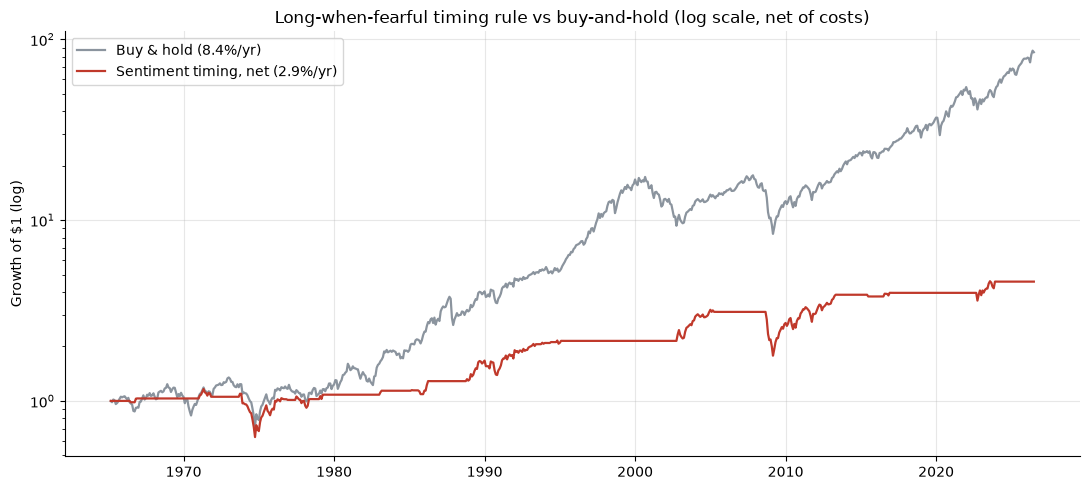

Timing rule (long in low-sentiment months, flat otherwise), net: 2.9%/yr
Unconditional buy-and-hold:                                    8.4%/yr
-> The timing rule LOSES to buy-and-hold by 5.5 pp/yr.
   Sitting out the high-sentiment months also sits out a lot of upside.


In [5]:
if HAVE_REAL:
    ov = st.timing_overlay(df, "ret", n_bins=3, short_high=False, one_way_bps=5.0)
    net = ov["net"]; bh = ov["buyhold"]
    cum_net = (1 + net).cumprod(); cum_bh = (1 + bh).cumprod()
    s_net = st.summarize(net); s_bh = st.summarize(bh)
    net_ann = s_net["mean"]*12*100; bh_ann = s_bh["mean"]*12*100
else:
    net_ann, bh_ann = R["ov_net_ann"], R["bh_ann"]
    cum_net = cum_bh = None

fig, ax = plt.subplots(figsize=(11, 5))
if cum_net is not None:
    ax.plot(cum_bh.index, cum_bh.values, color=GREY, lw=1.6, label=f"Buy & hold ({bh_ann:.1f}%/yr)")
    ax.plot(cum_net.index, cum_net.values, color=RED, lw=1.6, label=f"Sentiment timing, net ({net_ann:.1f}%/yr)")
    ax.set_yscale("log")
    ax.set_title("Long-when-fearful timing rule vs buy-and-hold (log scale, net of costs)")
    ax.set_ylabel("Growth of $1 (log)")
    ax.legend(fontsize=10)
else:
    ax.text(0.5, 0.5, f"Cache absent\nTiming {R['ov_net_ann']:.1f}%/yr  vs  Buy&hold {R['bh_ann']:.1f}%/yr",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=RED)
plt.tight_layout()
plt.savefig("../docs/timing_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Timing rule (long in low-sentiment months, flat otherwise), net: {R['ov_net_ann']:.1f}%/yr")
print(f"Unconditional buy-and-hold:                                    {R['bh_ann']:.1f}%/yr")
print(f"-> The timing rule LOSES to buy-and-hold by {R['bh_ann']-R['ov_net_ann']:.1f} pp/yr.")
print(f"   Sitting out the high-sentiment months also sits out a lot of upside.")


## The bottom line for the curious

Baker-Wurgler captures a *real psychological instinct* -- buy fear, sell greed -- and the
sign of the effect shows up faintly even on the broad S&P 500.  But:

- The aggregate-index spread is **not statistically significant** (HAC *t* = 0.32).
- A naive **timing rule loses to buy-and-hold** (2.9%/yr vs 8.4%/yr net) -- the
  fearful months you'd sit out contain too much of the market's long-run return.
- The cross-sectional leg (small-minus-large) has the right sign but is also
  insignificant on our proxy.

This is a **Weak / Mirage** result: the literature is real and the sign is right, but
there is no robust, tradable edge here on the aggregate index.


*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*